# Diseases Forecast in Kenyan's Public hospital

In [1]:
# importing the data from drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Library import

In [2]:
# lightgbm will be used for machine-learning forecasting.
!pip install -q lightgbm shap

In [3]:
# Importing the necessary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# changing pandas and seasborn settings
pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

# Set the default size of Matplotlib figures.
plt.rcParams["figure.figsize"] = (12, 6)

# Loading the Dataset

In [4]:
from pathlib import Path
# reading the data from drive
# PATH = "/content/drive/MyDrive/SIP_AB/data/kenya_disease_forecasting_training_synthetic_2018_2025.csv"

# df = pd.read_csv(PATH)
# df.tail()

# Defining the dataset path
PATH = Path(
    "/content/drive/MyDrive/SIP_AB/data/"
    "kenya_disease_forecasting_training_synthetic_2018_2025.csv"
)

# Checking file existance in the drive
if not PATH.exists():
    raise FileNotFoundError(
        f"The dataset was not found at:\n{PATH}\n\n"
        "Confirm that the filename and Google Drive folders are correct."
    )

print("Dataset found successfully.")
print("Dataset path:", PATH)

Dataset found successfully.
Dataset path: /content/drive/MyDrive/SIP_AB/data/kenya_disease_forecasting_training_synthetic_2018_2025.csv


In [5]:
# making copy from the origin dataset
raw_df = pd.read_csv(PATH)

# Create a working copy for cleaning and analysis.
df = raw_df.copy()

print("Dataset loaded successfully.")
print(f"Number of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]:,}")

Dataset loaded successfully.
Number of rows: 433,152
Number of columns: 34


In [6]:
# Standarise the column names and convert time
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_", regex=False)
)

# Check that the expected time column exists.
if "month" not in df.columns:
    raise KeyError(
        "The dataset does not contain a column named 'month'."
    )

# Convert the month column from text into Pandas datetime.
df["month"] = pd.to_datetime(
    df["month"],
    errors="coerce"
)

# Sort observations in correct time-series order.
sorting_columns = [
    "county",
    "disease",
    "age_group",
    "month"
]

# Only sort if all required sorting columns exist.
missing_sort_columns = [
    column for column in sorting_columns
    if column not in df.columns
]

if missing_sort_columns:
    print(
        "The following sorting columns are missing:",
        missing_sort_columns
    )
else:
    df = (
        df.sort_values(sorting_columns)
          .reset_index(drop=True)
    )

print("Column names standardised and dates converted.")

Column names standardised and dates converted.


In [7]:
# Dataset preview
print("First five observations:")
display(df.head())

print("\nLast five observations:")
display(df.tail())

print("\nRandom sample of five observations:")
display(df.sample(5, random_state=42))

First five observations:


,month,year,month_of_year,county,synthetic_public_facility_group,disease,age_group,cases,population,age_group_population,population_density,public_hospitals,testing_sites,healthcare_worker_density,rainfall_mm,temperature_c,humidity_pct,ndvi,flood_indicator,rainy_season,cases_lag_1m,cases_lag_2m,cases_lag_3m,cases_lag_6m,same_month_last_year,same_month_2_years_ago,same_month_3_years_ago,cases_avg_prev_3m,cases_avg_prev_6m,cases_avg_prev_12m,pct_change_vs_previous_month,pct_change_vs_same_month_last_year,target_next_month_cases,target_next_month_pct_change
0,2018-01-01,2018,1,Baringo,1,HIV,0-4,0,1758807,228644,88.9,23,45,1.77,45.21,22.08,69.40,0.378,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
1,2018-01-01,2018,1,Baringo,2,HIV,0-4,0,1758807,228644,88.9,23,45,1.77,92.38,23.23,64.62,0.439,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
2,2018-01-01,2018,1,Baringo,3,HIV,0-4,0,1758807,228644,88.9,23,45,1.77,70.16,23.50,51.37,0.363,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
3,2018-01-01,2018,1,Baringo,4,HIV,0-4,0,1758807,228644,88.9,23,45,1.77,58.04,24.32,67.64,0.462,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
4,2018-02-01,2018,2,Baringo,1,HIV,0-4,0,1761301,228969,88.9,23,45,1.77,47.93,21.27,65.63,0.548,0,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN,0.0,NaN



Last five observations:


,month,year,month_of_year,county,synthetic_public_facility_group,disease,age_group,cases,population,age_group_population,population_density,public_hospitals,testing_sites,healthcare_worker_density,rainfall_mm,temperature_c,humidity_pct,ndvi,flood_indicator,rainy_season,cases_lag_1m,cases_lag_2m,cases_lag_3m,cases_lag_6m,same_month_last_year,same_month_2_years_ago,same_month_3_years_ago,cases_avg_prev_3m,cases_avg_prev_6m,cases_avg_prev_12m,pct_change_vs_previous_month,pct_change_vs_same_month_last_year,target_next_month_cases,target_next_month_pct_change
433147,2025-11-01,2025,11,West Pokot,4,TB,65+,2,2483432,99337,829.9,31,50,3.69,132.04,24.57,77.46,0.599,0,1,0.0,0.0,2.0,0.0,0.0,1.0,0.0,0.67,0.50,0.25,NaN,NaN,0.0,-100.0
433148,2025-12-01,2025,12,West Pokot,1,TB,65+,1,2487617,99504,829.9,31,50,3.69,74.57,24.80,56.49,0.407,0,0,0.0,1.0,0.0,2.0,1.0,1.0,0.0,0.33,0.50,0.42,NaN,0.0,NaN,NaN
433149,2025-12-01,2025,12,West Pokot,2,TB,65+,0,2487617,99504,829.9,31,50,3.69,85.73,27.64,46.21,0.393,0,0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.33,0.33,0.42,-100.0,NaN,NaN,NaN
433150,2025-12-01,2025,12,West Pokot,3,TB,65+,0,2487617,99504,829.9,31,50,3.69,81.78,23.75,51.06,0.610,0,0,3.0,2.0,4.0,1.0,1.0,1.0,0.0,3.00,2.00,1.17,-100.0,-100.0,NaN,NaN
433151,2025-12-01,2025,12,West Pokot,4,TB,65+,0,2487617,99504,829.9,31,50,3.69,97.85,21.83,61.98,0.462,0,0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.67,0.83,0.42,-100.0,NaN,NaN,NaN



Random sample of five observations:


,month,year,month_of_year,county,synthetic_public_facility_group,disease,age_group,cases,population,age_group_population,population_density,public_hospitals,testing_sites,healthcare_worker_density,rainfall_mm,temperature_c,humidity_pct,ndvi,flood_indicator,rainy_season,cases_lag_1m,cases_lag_2m,cases_lag_3m,cases_lag_6m,same_month_last_year,same_month_2_years_ago,same_month_3_years_ago,cases_avg_prev_3m,cases_avg_prev_6m,cases_avg_prev_12m,pct_change_vs_previous_month,pct_change_vs_same_month_last_year,target_next_month_cases,target_next_month_pct_change
296397,2024-12-01,2024,12,Narok,2,HIV,35-44,1,1982154,237858,452.2,20,28,3.68,59.77,23.15,58.33,0.401,0,0,2.0,1.0,3.0,2.0,1.0,3.0,1.0,2.00,2.67,2.00,-50.0,0.00,8.0,700.00
315803,2021-03-01,2021,3,Nyandarua,4,HIV,55-64,1,1472289,73614,650.2,23,49,3.55,130.37,24.77,74.61,0.546,0,1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.00,0.50,0.33,NaN,NaN,0.0,-100.00
305325,2018-12-01,2018,12,Nyamira,2,HIV,35-44,2,1028640,123436,554.8,13,22,1.97,69.90,24.23,57.86,0.513,0,0,2.0,0.0,0.0,3.0,NaN,NaN,NaN,0.67,1.67,1.73,0.0,NaN,2.0,0.00
261430,2024-06-01,2024,6,Murang'a,3,Malaria,0-4,39,1422579,184935,856.6,14,26,1.15,63.87,23.49,55.22,0.411,0,0,60.0,54.0,47.0,37.0,45.0,32.0,55.0,53.67,49.00,44.50,-35.0,-13.33,43.0,10.26
392956,2020-08-01,2020,8,Turkana,1,Malaria,65+,0,501755,20070,537.2,6,13,2.08,52.98,26.60,75.44,0.312,0,0,1.0,0.0,1.0,0.0,0.0,1.0,NaN,0.67,0.50,0.42,-100.0,NaN,0.0,NaN


# Data Structure

In [8]:
# Displaying the dimension and columns of the dataset
number_of_rows, number_of_columns = df.shape

print(f"Number of rows: {number_of_rows:,}")
print(f"Number of columns: {number_of_columns:,}")

print("\nDataset columns:")

# Enumerate gives every column a readable position number.
for position, column in enumerate(df.columns, start=1):
    print(f"{position:02d}. {column}")

Number of rows: 433,152
Number of columns: 34

Dataset columns:
01. month
02. year
03. month_of_year
04. county
05. synthetic_public_facility_group
06. disease
07. age_group
08. cases
09. population
10. age_group_population
11. population_density
12. public_hospitals
13. testing_sites
14. healthcare_worker_density
15. rainfall_mm
16. temperature_c
17. humidity_pct
18. ndvi
19. flood_indicator
20. rainy_season
21. cases_lag_1m
22. cases_lag_2m
23. cases_lag_3m
24. cases_lag_6m
25. same_month_last_year
26. same_month_2_years_ago
27. same_month_3_years_ago
28. cases_avg_prev_3m
29. cases_avg_prev_6m
30. cases_avg_prev_12m
31. pct_change_vs_previous_month
32. pct_change_vs_same_month_last_year
33. target_next_month_cases
34. target_next_month_pct_change


In [9]:
# Inspecting the data stype
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 433152 entries, 0 to 433151
Data columns (total 34 columns):
 #   Column                              Non-Null Count   Dtype         
---  ------                              --------------   -----         
 0   month                               433152 non-null  datetime64[ns]
 1   year                                433152 non-null  int64         
 2   month_of_year                       433152 non-null  int64         
 3   county                              433152 non-null  object        
 4   synthetic_public_facility_group     433152 non-null  int64         
 5   disease                             433152 non-null  object        
 6   age_group                           433152 non-null  object        
 7   cases                               433152 non-null  int64         
 8   population                          433152 non-null  int64         
 9   age_group_population                433152 non-null  int64         
 10  populati

In [10]:
# Identifying numeric features
numeric_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

# Identifying categorical features
categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

# Identify date columns.
datetime_columns = df.select_dtypes(
    include=["datetime", "datetimetz"]
).columns.tolist()

print("Number of numeric columns:", len(numeric_columns))
print(numeric_columns)

print("\nNumber of categorical columns:", len(categorical_columns))
print(categorical_columns)

print("\nNumber of datetime columns:", len(datetime_columns))
print(datetime_columns)

Number of numeric columns: 30
['year', 'month_of_year', 'synthetic_public_facility_group', 'cases', 'population', 'age_group_population', 'population_density', 'public_hospitals', 'testing_sites', 'healthcare_worker_density', 'rainfall_mm', 'temperature_c', 'humidity_pct', 'ndvi', 'flood_indicator', 'rainy_season', 'cases_lag_1m', 'cases_lag_2m', 'cases_lag_3m', 'cases_lag_6m', 'same_month_last_year', 'same_month_2_years_ago', 'same_month_3_years_ago', 'cases_avg_prev_3m', 'cases_avg_prev_6m', 'cases_avg_prev_12m', 'pct_change_vs_previous_month', 'pct_change_vs_same_month_last_year', 'target_next_month_cases', 'target_next_month_pct_change']

Number of categorical columns: 3
['county', 'disease', 'age_group']

Number of datetime columns: 1
['month']


In [11]:
# Forecasting structure

# Columns define one disease forecasting series.
series_columns = [
    "county",
    "disease",
    "age_group"
]

# Columns should uniquely identify one observation.
panel_key = [
    "month",
    "county",
    "disease",
    "age_group"
]

required_structure_columns = set(
    series_columns + ["month"]
)

missing_structure_columns = sorted(
    required_structure_columns - set(df.columns)
)

if missing_structure_columns:
    print(
        "Missing structure columns:",
        missing_structure_columns
    )

else:
    # Count the number of different time-series combinations.
    number_of_series = (
        df.groupby(series_columns)
          .ngroups
    )

    print(f"Number of forecasting series: {number_of_series:,}")
    print(
        "Each series represents one "
        "county × disease × age-group combination."
    )

Number of forecasting series: 1,128
Each series represents one county × disease × age-group combination.


In [12]:
# Observations per forecasting

if all(column in df.columns for column in series_columns):

    series_summary = (
        df.groupby(series_columns)
          .agg(
              first_month=("month", "min"),
              last_month=("month", "max"),
              months_present=("month", "nunique"),
              records=("month", "size")
          )
          .reset_index()
    )

    print("Example forecasting series:")
    display(series_summary.head(10))

    print("\nDistribution of the number of months per series:")
    display(
        series_summary["months_present"]
        .describe()
        .to_frame("value")
    )

Example forecasting series:


,county,disease,age_group,first_month,last_month,months_present,records
0,Baringo,HIV,0-4,2018-01-01,2025-12-01,96,384
1,Baringo,HIV,15-24,2018-01-01,2025-12-01,96,384
2,Baringo,HIV,25-34,2018-01-01,2025-12-01,96,384
3,Baringo,HIV,35-44,2018-01-01,2025-12-01,96,384
4,Baringo,HIV,45-54,2018-01-01,2025-12-01,96,384
5,Baringo,HIV,5-14,2018-01-01,2025-12-01,96,384
6,Baringo,HIV,55-64,2018-01-01,2025-12-01,96,384
7,Baringo,HIV,65+,2018-01-01,2025-12-01,96,384
8,Baringo,Malaria,0-4,2018-01-01,2025-12-01,96,384
9,Baringo,Malaria,15-24,2018-01-01,2025-12-01,96,384



Distribution of the number of months per series:


,value
count,1128.0
mean,96.0
std,0.0
min,96.0
25%,96.0
50%,96.0
75%,96.0
max,96.0


# checking for the missing values

In [13]:
# Count the number of missing values in each column.
missing_count = df.isna().sum()

# Calculate the percentage of missing values in each column.
missing_percentage = (
    df.isna().mean() * 100
)

# Combine the results into one table.
missing_report = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percentage": missing_percentage
})

# Keep only columns containing at least one missing value.
missing_report = (
    missing_report
    .query("missing_count > 0")
    .sort_values(
        "missing_percentage",
        ascending=False
    )
)

if missing_report.empty:
    print("No missing values were found.")

else:
    print("Columns containing missing values:")

    display(
        missing_report.style.format({
            "missing_percentage": "{:.2f}%"
        })
    )

Columns containing missing values:


,missing_count,missing_percentage
pct_change_vs_same_month_last_year,166369,38.41%
same_month_3_years_ago,162432,37.50%
target_next_month_pct_change,130785,30.19%
pct_change_vs_previous_month,130785,30.19%
same_month_2_years_ago,108288,25.00%
same_month_last_year,54144,12.50%
cases_lag_6m,27072,6.25%
cases_lag_3m,13536,3.12%
cases_lag_2m,9024,2.08%
cases_lag_1m,4512,1.04%


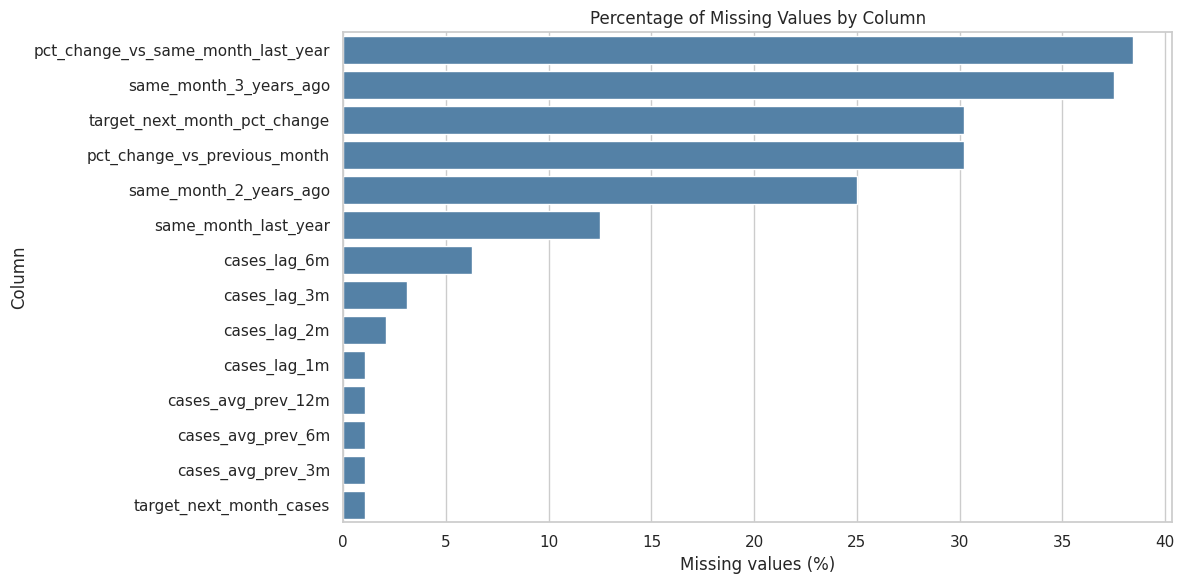

In [14]:
# Visualizing the missing values in the dataset

if not missing_report.empty:

    plt.figure(figsize=(12, 6))

    sns.barplot(
        data=missing_report.reset_index(),
        x="missing_percentage",
        y="index",
        color="steelblue"
    )

    plt.title("Percentage of Missing Values by Column")
    plt.xlabel("Missing values (%)")
    plt.ylabel("Column")
    plt.tight_layout()
    plt.show()

In [15]:
# Checking for the duplicate values
df.duplicated().sum()

np.int64(0)

In [16]:
# checking for the invalid date formationg
invalid_date_count = df["month"].isna().sum()

print(
    f"Invalid or missing dates: "
    f"{invalid_date_count:,}"
)

if invalid_date_count > 0:
    display(
        df[df["month"].isna()].head(20)
    )

Invalid or missing dates: 0


In [17]:

# Summary of the data quality

quality_summary = pd.Series({
    "number_of_rows": len(df),
    "number_of_columns": df.shape[1],
    "invalid_dates": df["month"].isna().sum(),
    "exact_duplicate_rows": df.duplicated().sum(),
    "duplicate_panel_rows": (
        df.duplicated(panel_key, keep=False).sum()
        if all(column in df.columns for column in panel_key)
        else np.nan
    ),
    "columns_with_missing_values": (
        df.isna().any().sum()
    ),
    "total_missing_values": (
        df.isna().sum().sum()
    ),
    "total_infinite_values": (
        np.isinf(
            df.select_dtypes(include=np.number)
        ).sum().sum()
    )
})

display(
    quality_summary.to_frame("value")
)

,value
number_of_rows,433152
number_of_columns,34
invalid_dates,0
exact_duplicate_rows,0
duplicate_panel_rows,433152
columns_with_missing_values,14
total_missing_values,824995
total_infinite_values,0


In [18]:
# Sort each forecasting series chronologically
group_cols = ["county", "disease", "age_group"]

df = (
    df.sort_values(group_cols + ["month"])
      .reset_index(drop=True)
)

print("Data sorted successfully.")
print("Shape:", df.shape)

Data sorted successfully.
Shape: (433152, 34)


In [19]:
# Group cases by county, disease and age group
cases_group = df.groupby(
    group_cols,
    sort=False
)["cases"]

lag_definitions = {
    "cases_previous_month": 1,
    "cases_2_months_ago": 2,
    "cases_3_months_ago": 3,
    "cases_6_months_ago": 6,
    "cases_12_months_ago": 12,
    "same_month_last_year": 12,
    "same_month_2_years_ago": 24,
    "same_month_3_years_ago": 36
}

validation_results = []

for column, lag in lag_definitions.items():

    if column not in df.columns:
        continue

    expected = cases_group.shift(lag)

    comparable = (
        df[column].notna()
        & expected.notna()
    )

    mismatches = (
        ~np.isclose(
            df.loc[comparable, column],
            expected.loc[comparable]
        )
    ).sum()

    validation_results.append({
        "column": column,
        "values_compared": comparable.sum(),
        "mismatches": mismatches
    })

lag_validation = pd.DataFrame(validation_results)

display(lag_validation)

,column,values_compared,mismatches
0,same_month_last_year,379008,274176
1,same_month_2_years_ago,324864,234505
2,same_month_3_years_ago,270720,196107


In [20]:
panel_key = [
    "month",
    "county",
    "disease",
    "age_group"
]

duplicate_mask = df.duplicated(
    subset=panel_key,
    keep=False
)

print("Total rows:", len(df))
print("Rows with duplicated panel keys:", duplicate_mask.sum())
print(
    "Unique forecasting observations:",
    df[panel_key].drop_duplicates().shape[0]
)

display(
    df.loc[duplicate_mask]
      .sort_values(panel_key)
      .head(12)
)

Total rows: 433152
Rows with duplicated panel keys: 433152
Unique forecasting observations: 108288


,month,year,month_of_year,county,synthetic_public_facility_group,disease,age_group,cases,population,age_group_population,population_density,public_hospitals,testing_sites,healthcare_worker_density,rainfall_mm,temperature_c,humidity_pct,ndvi,flood_indicator,rainy_season,cases_lag_1m,cases_lag_2m,cases_lag_3m,cases_lag_6m,same_month_last_year,same_month_2_years_ago,same_month_3_years_ago,cases_avg_prev_3m,cases_avg_prev_6m,cases_avg_prev_12m,pct_change_vs_previous_month,pct_change_vs_same_month_last_year,target_next_month_cases,target_next_month_pct_change
0,2018-01-01,2018,1,Baringo,1,HIV,0-4,0,1758807,228644,88.9,23,45,1.77,45.21,22.08,69.40,0.378,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
1,2018-01-01,2018,1,Baringo,2,HIV,0-4,0,1758807,228644,88.9,23,45,1.77,92.38,23.23,64.62,0.439,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
2,2018-01-01,2018,1,Baringo,3,HIV,0-4,0,1758807,228644,88.9,23,45,1.77,70.16,23.50,51.37,0.363,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
3,2018-01-01,2018,1,Baringo,4,HIV,0-4,0,1758807,228644,88.9,23,45,1.77,58.04,24.32,67.64,0.462,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
384,2018-01-01,2018,1,Baringo,1,HIV,15-24,3,1758807,316585,88.9,23,45,1.77,63.58,22.69,60.35,0.293,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,-33.33
385,2018-01-01,2018,1,Baringo,2,HIV,15-24,4,1758807,316585,88.9,23,45,1.77,70.55,21.92,61.63,0.556,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,-50.00
386,2018-01-01,2018,1,Baringo,3,HIV,15-24,1,1758807,316585,88.9,23,45,1.77,46.30,20.61,67.62,0.522,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,-100.00
387,2018-01-01,2018,1,Baringo,4,HIV,15-24,5,1758807,316585,88.9,23,45,1.77,74.75,23.86,54.82,0.448,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,0.00
768,2018-01-01,2018,1,Baringo,1,HIV,25-34,1,1758807,281409,88.9,23,45,1.77,38.98,27.20,61.01,0.584,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,100.00
769,2018-01-01,2018,1,Baringo,2,HIV,25-34,1,1758807,281409,88.9,23,45,1.77,70.76,24.26,57.88,0.467,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,-100.00


In [21]:
aggregation_rules = {
    "cases": "sum",

    # These should be identical across the four facility rows
    "population": "first",
    "age_group_population": "first",
    "population_density": "first",
    "public_hospitals": "first",
    "testing_sites": "first",
    "healthcare_worker_density": "first",

    # Average environmental measurements
    "rainfall_mm": "mean",
    "temperature_c": "mean",
    "humidity_pct": "mean",
    "ndvi": "mean",

    # Retain 1 if any facility record has the indicator
    "flood_indicator": "max",
    "rainy_season": "max"
}

# Keep only rules for columns that exist
aggregation_rules = {
    column: method
    for column, method in aggregation_rules.items()
    if column in df.columns
}

agg_df = (
    df.groupby(panel_key, as_index=False)
      .agg(aggregation_rules)
)

agg_df["year"] = agg_df["month"].dt.year
agg_df["month_of_year"] = agg_df["month"].dt.month

print("Original rows:", f"{len(df):,}")
print("Aggregated rows:", f"{len(agg_df):,}")
print(
    "Duplicate keys after aggregation:",
    agg_df.duplicated(panel_key).sum()
)

display(agg_df.head())

Original rows: 433,152
Aggregated rows: 108,288
Duplicate keys after aggregation: 0


,month,county,disease,age_group,cases,population,age_group_population,population_density,public_hospitals,testing_sites,healthcare_worker_density,rainfall_mm,temperature_c,humidity_pct,ndvi,flood_indicator,rainy_season,year,month_of_year
0,2018-01-01,Baringo,HIV,0-4,0,1758807,228644,88.9,23,45,1.77,66.4475,23.2825,63.2575,0.41050,0,0,2018,1
1,2018-01-01,Baringo,HIV,15-24,13,1758807,316585,88.9,23,45,1.77,63.7950,22.2700,61.1050,0.45475,0,0,2018,1
2,2018-01-01,Baringo,HIV,25-34,10,1758807,281409,88.9,23,45,1.77,73.3325,24.7475,63.8300,0.48625,0,0,2018,1
3,2018-01-01,Baringo,HIV,35-44,10,1758807,211056,88.9,23,45,1.77,57.9100,24.4325,57.8500,0.42850,0,0,2018,1
4,2018-01-01,Baringo,HIV,45-54,5,1758807,140704,88.9,23,45,1.77,70.0300,21.4700,59.7750,0.37325,0,0,2018,1


In [22]:
original_cases = df["cases"].sum()
aggregated_cases = agg_df["cases"].sum()

print("Original total cases:", f"{original_cases:,.0f}")
print("Aggregated total cases:", f"{aggregated_cases:,.0f}")
print("Difference:", aggregated_cases - original_cases)

assert np.isclose(original_cases, aggregated_cases)

print("Case totals reconciled successfully.")

Original total cases: 6,658,485
Aggregated total cases: 6,658,485
Difference: 0
Case totals reconciled successfully.


In [23]:
df = agg_df.copy()

df = (
    df.sort_values(
        ["county", "disease", "age_group", "month"]
    )
    .reset_index(drop=True)
)

print("Working dataset shape:", df.shape)

Working dataset shape: (108288, 19)


In [24]:
# Sort each time series before creating historical features
series_cols = ["county", "disease", "age_group"]

df = (
    df.sort_values(series_cols + ["month"])
      .reset_index(drop=True)
)

cases_group = df.groupby(
    series_cols,
    sort=False
)["cases"]

# Historical case features
for lag in [1, 2, 3, 6, 12, 24, 36]:
    df[f"cases_lag_{lag}m"] = cases_group.shift(lag)

# Rolling averages include information available in the current month
for window in [3, 6, 12]:
    df[f"cases_avg_{window}m"] = cases_group.transform(
        lambda x: x.rolling(
            window=window,
            min_periods=window
        ).mean()
    )

# Percentage change from the previous month
previous_cases = df["cases_lag_1m"].replace(0, np.nan)

df["pct_change_previous_month"] = (
    (df["cases"] - df["cases_lag_1m"])
    / previous_cases
    * 100
)

# Population-adjusted disease burden
df["cases_per_100k"] = (
    df["cases"]
    / df["age_group_population"].replace(0, np.nan)
    * 100_000
)

# Cyclical representation of the month
df["month_sin"] = np.sin(
    2 * np.pi * df["month_of_year"] / 12
)

df["month_cos"] = np.cos(
    2 * np.pi * df["month_of_year"] / 12
)

# Target: cases in the following month
df["target_next_month_cases"] = cases_group.shift(-1)

print("Dataset shape:", df.shape)
display(df.head(15))

Dataset shape: (108288, 34)


,month,county,disease,age_group,cases,population,age_group_population,population_density,public_hospitals,testing_sites,healthcare_worker_density,rainfall_mm,temperature_c,humidity_pct,ndvi,flood_indicator,rainy_season,year,month_of_year,cases_lag_1m,cases_lag_2m,cases_lag_3m,cases_lag_6m,cases_lag_12m,cases_lag_24m,cases_lag_36m,cases_avg_3m,cases_avg_6m,cases_avg_12m,pct_change_previous_month,cases_per_100k,month_sin,month_cos,target_next_month_cases
0,2018-01-01,Baringo,HIV,0-4,0,1758807,228644,88.9,23,45,1.77,66.4475,23.2825,63.2575,0.41050,0,0,2018,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,5.000000e-01,8.660254e-01,0.0
1,2018-02-01,Baringo,HIV,0-4,0,1761301,228969,88.9,23,45,1.77,71.8600,23.1825,65.0475,0.45825,0,0,2018,2,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,8.660254e-01,5.000000e-01,2.0
2,2018-03-01,Baringo,HIV,0-4,2,1763799,229293,88.9,23,45,1.77,135.1450,24.3700,78.9550,0.50125,1,1,2018,3,0.0,0.0,NaN,NaN,NaN,NaN,NaN,0.666667,NaN,NaN,NaN,0.872246,1.000000e+00,6.123234e-17,1.0
3,2018-04-01,Baringo,HIV,0-4,1,1766300,229619,88.9,23,45,1.77,150.3225,23.3350,74.5700,0.47950,1,1,2018,4,2.0,0.0,0.0,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,-50.000000,0.435504,8.660254e-01,-5.000000e-01,1.0
4,2018-05-01,Baringo,HIV,0-4,1,1768805,229944,88.9,23,45,1.77,140.9100,23.7750,77.3300,0.55125,1,1,2018,5,1.0,2.0,0.0,NaN,NaN,NaN,NaN,1.333333,NaN,NaN,0.000000,0.434888,5.000000e-01,-8.660254e-01,2.0
5,2018-06-01,Baringo,HIV,0-4,2,1771314,230270,88.9,23,45,1.77,68.8900,23.4050,62.1900,0.38350,0,0,2018,6,1.0,1.0,2.0,NaN,NaN,NaN,NaN,1.333333,1.000000,NaN,100.000000,0.868546,1.224647e-16,-1.000000e+00,3.0
6,2018-07-01,Baringo,HIV,0-4,3,1773826,230597,88.9,23,45,1.77,74.8350,24.3625,57.3175,0.45400,0,0,2018,7,2.0,1.0,1.0,0.0,NaN,NaN,NaN,2.000000,1.500000,NaN,50.000000,1.300971,-5.000000e-01,-8.660254e-01,3.0
7,2018-08-01,Baringo,HIV,0-4,3,1776342,230924,88.9,23,45,1.77,51.5100,25.2875,62.0000,0.43125,0,0,2018,8,3.0,2.0,1.0,0.0,NaN,NaN,NaN,2.666667,2.000000,NaN,0.000000,1.299129,-8.660254e-01,-5.000000e-01,2.0
8,2018-09-01,Baringo,HIV,0-4,2,1778861,231251,88.9,23,45,1.77,59.5800,24.5025,64.7475,0.44025,0,0,2018,9,3.0,3.0,2.0,2.0,NaN,NaN,NaN,2.666667,2.000000,NaN,-33.333333,0.864861,-1.000000e+00,-1.836970e-16,0.0
9,2018-10-01,Baringo,HIV,0-4,0,1781384,231579,88.9,23,45,1.77,126.0175,23.3775,72.0025,0.55350,0,1,2018,10,2.0,3.0,3.0,1.0,NaN,NaN,NaN,1.666667,1.833333,NaN,-100.000000,0.000000,-8.660254e-01,5.000000e-01,1.0


,records,total_cases,mean_cases,median_cases,maximum_cases
disease,,,,,
HIV,36096,178922,4.96,3.0,68
Malaria,36096,6241322,172.91,107.5,2132
TB,36096,238241,6.60,5.0,83


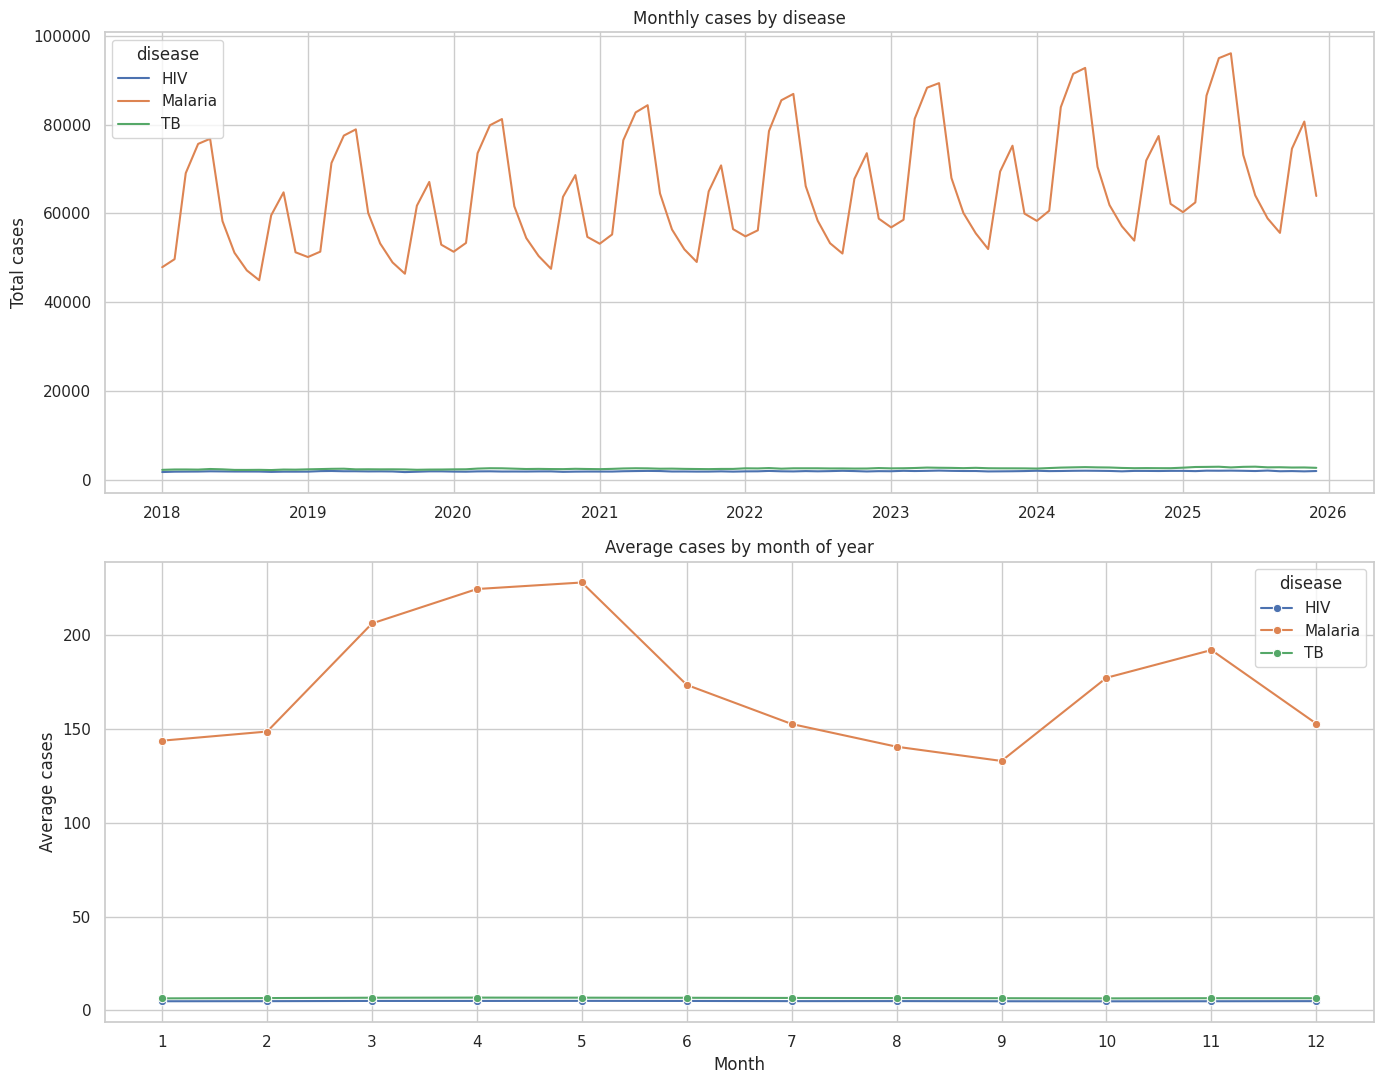

In [25]:
# Summary of case counts by disease
disease_summary = (
    df.groupby("disease")["cases"]
      .agg(
          records="count",
          total_cases="sum",
          mean_cases="mean",
          median_cases="median",
          maximum_cases="max"
      )
      .round(2)
)

display(disease_summary)

# National monthly totals
monthly_cases = (
    df.groupby(
        ["month", "disease"],
        as_index=False
    )["cases"]
    .sum()
)

fig, axes = plt.subplots(2, 1, figsize=(14, 11))

sns.lineplot(
    data=monthly_cases,
    x="month",
    y="cases",
    hue="disease",
    ax=axes[0]
)

axes[0].set_title("Monthly cases by disease")
axes[0].set_xlabel("")
axes[0].set_ylabel("Total cases")

# Average seasonal pattern
seasonal_cases = (
    df.groupby(
        ["month_of_year", "disease"],
        as_index=False
    )["cases"]
    .mean()
)

sns.lineplot(
    data=seasonal_cases,
    x="month_of_year",
    y="cases",
    hue="disease",
    marker="o",
    ax=axes[1]
)

axes[1].set_title("Average cases by month of year")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Average cases")
axes[1].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

In [26]:
target = "target_next_month_cases"

categorical_features = [
    "county",
    "disease",
    "age_group"
]

numeric_features = [
    "year",
    "month_of_year",
    "month_sin",
    "month_cos",
    "cases",
    "cases_lag_1m",
    "cases_lag_2m",
    "cases_lag_3m",
    "cases_lag_6m",
    "cases_lag_12m",
    "cases_lag_24m",
    "cases_lag_36m",
    "cases_avg_3m",
    "cases_avg_6m",
    "cases_avg_12m",
    "pct_change_previous_month",
    "cases_per_100k",
    "population",
    "age_group_population",
    "population_density",
    "rainfall_mm",
    "temperature_c",
    "humidity_pct",
    "ndvi",
    "flood_indicator",
    "public_hospitals",
    "testing_sites",
    "healthcare_worker_density",
    "rainy_season"
]

features = categorical_features + numeric_features

# Remove only observations without a known future target
model_df = df.loc[
    df[target].notna(),
    ["month"] + features + [target]
].copy()

# Convert infinite percentage changes to missing values
model_df.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)

print("Model-ready shape:", model_df.shape)
print("Target missing values:", model_df[target].isna().sum())
print("Predictor count:", len(features))

display(model_df.head())

Model-ready shape: (107160, 34)
Target missing values: 0
Predictor count: 32


,month,county,disease,age_group,year,month_of_year,month_sin,month_cos,cases,cases_lag_1m,cases_lag_2m,cases_lag_3m,cases_lag_6m,cases_lag_12m,cases_lag_24m,cases_lag_36m,cases_avg_3m,cases_avg_6m,cases_avg_12m,pct_change_previous_month,cases_per_100k,population,age_group_population,population_density,rainfall_mm,temperature_c,humidity_pct,ndvi,flood_indicator,public_hospitals,testing_sites,healthcare_worker_density,rainy_season,target_next_month_cases
0,2018-01-01,Baringo,HIV,0-4,2018,1,0.500000,8.660254e-01,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1758807,228644,88.9,66.4475,23.2825,63.2575,0.41050,0,23,45,1.77,0,0.0
1,2018-02-01,Baringo,HIV,0-4,2018,2,0.866025,5.000000e-01,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1761301,228969,88.9,71.8600,23.1825,65.0475,0.45825,0,23,45,1.77,0,2.0
2,2018-03-01,Baringo,HIV,0-4,2018,3,1.000000,6.123234e-17,2,0.0,0.0,NaN,NaN,NaN,NaN,NaN,0.666667,NaN,NaN,NaN,0.872246,1763799,229293,88.9,135.1450,24.3700,78.9550,0.50125,1,23,45,1.77,1,1.0
3,2018-04-01,Baringo,HIV,0-4,2018,4,0.866025,-5.000000e-01,1,2.0,0.0,0.0,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,-50.0,0.435504,1766300,229619,88.9,150.3225,23.3350,74.5700,0.47950,1,23,45,1.77,1,1.0
4,2018-05-01,Baringo,HIV,0-4,2018,5,0.500000,-8.660254e-01,1,1.0,2.0,0.0,NaN,NaN,NaN,NaN,1.333333,NaN,NaN,0.0,0.434888,1768805,229944,88.9,140.9100,23.7750,77.3300,0.55125,1,23,45,1.77,1,2.0


In [27]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Train on 2018–2023, validate on 2024 and test on 2025
train_df = model_df[
    model_df["month"] <= "2023-12-01"
].copy()

valid_df = model_df[
    model_df["month"].between(
        "2024-01-01",
        "2024-12-01"
    )
].copy()

test_df = model_df[
    model_df["month"] >= "2025-01-01"
].copy()

split_summary = pd.DataFrame({
    "split": ["Training", "Validation", "Testing"],
    "first_month": [
        train_df["month"].min(),
        valid_df["month"].min(),
        test_df["month"].min()
    ],
    "last_month": [
        train_df["month"].max(),
        valid_df["month"].max(),
        test_df["month"].max()
    ],
    "rows": [
        len(train_df),
        len(valid_df),
        len(test_df)
    ]
})

display(split_summary)

# Evaluate persistence and seasonal baselines
def evaluate_baselines(data, split_name):

    results = []

    baselines = {
        "Persistence": "cases",
        "Seasonal 12-month": "cases_lag_12m"
    }

    for disease, disease_data in data.groupby("disease"):

        for baseline_name, prediction_col in baselines.items():

            usable = disease_data[
                [target, prediction_col]
            ].dropna()

            actual = usable[target]
            predicted = usable[prediction_col]

            results.append({
                "split": split_name,
                "disease": disease,
                "baseline": baseline_name,
                "observations": len(usable),
                "MAE": mean_absolute_error(
                    actual,
                    predicted
                ),
                "RMSE": np.sqrt(
                    mean_squared_error(
                        actual,
                        predicted
                    )
                ),
                "R2": r2_score(
                    actual,
                    predicted
                )
            })

    return pd.DataFrame(results)


baseline_results = pd.concat(
    [
        evaluate_baselines(
            valid_df,
            "Validation 2024"
        ),
        evaluate_baselines(
            test_df,
            "Testing 2025"
        )
    ],
    ignore_index=True
)

display(
    baseline_results.round({
        "MAE": 2,
        "RMSE": 2,
        "R2": 3
    })
)

,split,first_month,last_month,rows
0,Training,2018-01-01,2023-12-01,81216
1,Validation,2024-01-01,2024-12-01,13536
2,Testing,2025-01-01,2025-11-01,12408


,split,disease,baseline,observations,MAE,RMSE,R2
0,Validation 2024,HIV,Persistence,4512,1.94,2.90,0.795
1,Validation 2024,HIV,Seasonal 12-month,4512,2.34,3.40,0.719
2,Validation 2024,Malaria,Persistence,4512,28.77,50.68,0.941
3,Validation 2024,Malaria,Seasonal 12-month,4512,29.76,51.84,0.939
4,Validation 2024,TB,Persistence,4512,2.33,3.26,0.803
5,Validation 2024,TB,Seasonal 12-month,4512,2.78,3.91,0.717
6,Testing 2025,HIV,Persistence,4136,1.99,2.93,0.803
7,Testing 2025,HIV,Seasonal 12-month,4136,2.33,3.40,0.734
8,Testing 2025,Malaria,Persistence,4136,31.80,56.08,0.936
9,Testing 2025,Malaria,Seasonal 12-month,4136,32.65,56.13,0.935


# Model Training

In [28]:
# Install LightGBM if it is not already available
!pip install -q lightgbm

import lightgbm as lgb

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("LightGBM version:", lgb.__version__)

LightGBM version: 4.6.0


# Model Architecture

In [29]:
# Disease is excluded because each disease gets its own model
model_features = [
    feature for feature in features
    if feature != "disease"
]

model_categorical = [
    "county",
    "age_group"
]

models = {}
validation_predictions = {}
training_results = []

for disease in sorted(train_df["disease"].unique()):

    train_part = train_df[
        train_df["disease"] == disease
    ].copy()

    valid_part = valid_df[
        valid_df["disease"] == disease
    ].copy()

    X_train = train_part[model_features].copy()
    y_train = train_part[target]

    X_valid = valid_part[model_features].copy()
    y_valid = valid_part[target]

    # Use identical categories in training and validation
    for column in model_categorical:

        categories = sorted(
            X_train[column].dropna().unique()
        )

        X_train[column] = pd.Categorical(
            X_train[column],
            categories=categories
        )

        X_valid[column] = pd.Categorical(
            X_valid[column],
            categories=categories
        )

    model = lgb.LGBMRegressor(
        objective="regression_l1",
        n_estimators=2000,
        learning_rate=0.03,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=30,
        subsample=0.8,
        subsample_freq=1,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )

    model.fit(
        X_train,
        y_train,
        categorical_feature=model_categorical,
        eval_set=[(X_valid, y_valid)],
        eval_metric="mae",
        callbacks=[
            lgb.early_stopping(
                stopping_rounds=100,
                verbose=False
            ),
            lgb.log_evaluation(0)
        ]
    )

    predictions = model.predict(
        X_valid,
        num_iteration=model.best_iteration_
    )

    # Disease cases cannot be negative
    predictions = np.clip(predictions, 0, None)

    models[disease] = model
    validation_predictions[disease] = predictions

    training_results.append({
        "disease": disease,
        "training_rows": len(train_part),
        "validation_rows": len(valid_part),
        "best_iteration": model.best_iteration_
    })

display(pd.DataFrame(training_results))

,disease,training_rows,validation_rows,best_iteration
0,HIV,27072,4512,305
1,Malaria,27072,4512,1550
2,TB,27072,4512,402


# model Evaluation

In [30]:
validation_results = []
prediction_tables = []

for disease, predictions in validation_predictions.items():

    actual_data = (
        valid_df[valid_df["disease"] == disease]
        .copy()
    )

    actual = actual_data[target].to_numpy()

    mae = mean_absolute_error(
        actual,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predictions
        )
    )

    r2 = r2_score(
        actual,
        predictions
    )

    # WAPE is safer than MAPE when actual cases can equal zero
    wape = (
        np.abs(actual - predictions).sum()
        / np.abs(actual).sum()
        * 100
    )

    bias = np.mean(predictions - actual)

    validation_results.append({
        "disease": disease,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "WAPE_percent": wape,
        "bias": bias
    })

    disease_predictions = actual_data[
        [
            "month",
            "county",
            "disease",
            "age_group",
            "cases",
            target
        ]
    ].copy()

    disease_predictions["predicted_cases"] = predictions

    disease_predictions["absolute_error"] = np.abs(
        disease_predictions[target]
        - disease_predictions["predicted_cases"]
    )

    prediction_tables.append(disease_predictions)

validation_metrics = pd.DataFrame(
    validation_results
)

validation_output = pd.concat(
    prediction_tables,
    ignore_index=True
)

display(
    validation_metrics.round({
        "MAE": 2,
        "RMSE": 2,
        "R2": 3,
        "WAPE_percent": 2,
        "bias": 2
    })
)

,disease,MAE,RMSE,R2,WAPE_percent,bias
0,HIV,1.64,2.36,0.864,31.79,-0.20
1,Malaria,11.27,18.65,0.992,6.03,-1.27
2,TB,1.96,2.73,0.862,27.86,-0.28


In [31]:
model_comparison = validation_metrics[
    [
        "disease",
        "MAE",
        "RMSE",
        "R2"
    ]
].copy()

model_comparison["model"] = "LightGBM"

baseline_comparison = (
    baseline_results[
        baseline_results["split"] == "Validation 2024"
    ]
    [
        [
            "disease",
            "baseline",
            "MAE",
            "RMSE",
            "R2"
        ]
    ]
    .rename(columns={"baseline": "model"})
)

comparison = pd.concat(
    [
        baseline_comparison,
        model_comparison
    ],
    ignore_index=True
)

comparison = comparison.sort_values(
    ["disease", "MAE"]
)

display(
    comparison.round({
        "MAE": 2,
        "RMSE": 2,
        "R2": 3
    })
)

,disease,model,MAE,RMSE,R2
6,HIV,LightGBM,1.64,2.36,0.864
0,HIV,Persistence,1.94,2.90,0.795
1,HIV,Seasonal 12-month,2.34,3.40,0.719
7,Malaria,LightGBM,11.27,18.65,0.992
2,Malaria,Persistence,28.77,50.68,0.941
3,Malaria,Seasonal 12-month,29.76,51.84,0.939
8,TB,LightGBM,1.96,2.73,0.862
4,TB,Persistence,2.33,3.26,0.803
5,TB,Seasonal 12-month,2.78,3.91,0.717


In [35]:
def forecasting_metrics(actual, predicted):

    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)

    # Remove missing or infinite pairs
    valid = (
        np.isfinite(actual)
        & np.isfinite(predicted)
    )

    actual = actual[valid]
    predicted = predicted[valid]

    mae = mean_absolute_error(actual, predicted)

    rmse = np.sqrt(
        mean_squared_error(actual, predicted)
    )

    r2 = r2_score(actual, predicted)

    wape = (
        np.abs(actual - predicted).sum()
        / np.abs(actual).sum()
        * 100
    )

    # A practical forecasting accuracy measure
    forecast_accuracy = 100 - wape

    # Percentage within ±20%, excluding zero actual values
    nonzero = actual != 0

    relative_error = (
        np.abs(
            actual[nonzero] - predicted[nonzero]
        )
        / np.abs(actual[nonzero])
    )

    within_20_percent = (
        (relative_error <= 0.20).mean() * 100
    )

    bias = np.mean(predicted - actual)

    return {
        "observations": len(actual),
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "WAPE_percent": wape,
        "forecast_accuracy_percent": forecast_accuracy,
        "within_20_percent": within_20_percent,
        "bias": bias
    }

In [36]:
evaluation_rows = []

for disease in sorted(valid_df["disease"].unique()):

    disease_data = (
        valid_df[
            valid_df["disease"] == disease
        ]
        .copy()
    )

    actual = disease_data[target].to_numpy()

    predictions = {
        "Persistence": disease_data["cases"].to_numpy(),

        "Seasonal 12-month": (
            disease_data["cases_lag_12m"].to_numpy()
        ),

        "LightGBM": validation_predictions[disease]
    }

    for model_name, predicted in predictions.items():

        metrics = forecasting_metrics(
            actual,
            predicted
        )

        evaluation_rows.append({
            "disease": disease,
            "model": model_name,
            **metrics
        })

evaluation_matrix = pd.DataFrame(
    evaluation_rows
)

evaluation_matrix = evaluation_matrix.sort_values(
    ["disease", "MAE"]
)

display(
    evaluation_matrix.round({
        "MAE": 2,
        "RMSE": 2,
        "R2": 3,
        "WAPE_percent": 2,
        "forecast_accuracy_percent": 2,
        "within_20_percent": 2,
        "bias": 2
    })
)

,disease,model,observations,MAE,RMSE,R2,WAPE_percent,forecast_accuracy_percent,within_20_percent,bias
2,HIV,LightGBM,4512,1.64,2.36,0.864,31.79,68.21,37.76,-0.20
0,HIV,Persistence,4512,1.94,2.90,0.795,37.76,62.24,32.85,0.00
1,HIV,Seasonal 12-month,4512,2.34,3.40,0.719,45.45,54.55,27.65,-0.06
5,Malaria,LightGBM,4512,11.27,18.65,0.992,6.03,93.97,86.75,-1.27
3,Malaria,Persistence,4512,28.77,50.68,0.941,15.38,84.62,60.88,-0.44
4,Malaria,Seasonal 12-month,4512,29.76,51.84,0.939,15.91,84.09,59.38,-6.50
8,TB,LightGBM,4512,1.96,2.73,0.862,27.86,72.14,39.15,-0.28
6,TB,Persistence,4512,2.33,3.26,0.803,33.12,66.88,34.27,-0.04
7,TB,Seasonal 12-month,4512,2.78,3.91,0.717,39.51,60.49,29.56,-0.19


# Accuracy comparison table

In [37]:
accuracy_comparison = evaluation_matrix.pivot(
    index="disease",
    columns="model",
    values="forecast_accuracy_percent"
)

display(
    accuracy_comparison.round(2)
    .style.background_gradient(
        cmap="Greens",
        axis=None
    )
)

model,LightGBM,Persistence,Seasonal 12-month
disease,,,
HIV,68.210000,62.240000,54.550000
Malaria,93.970000,84.620000,84.090000
TB,72.140000,66.880000,60.490000


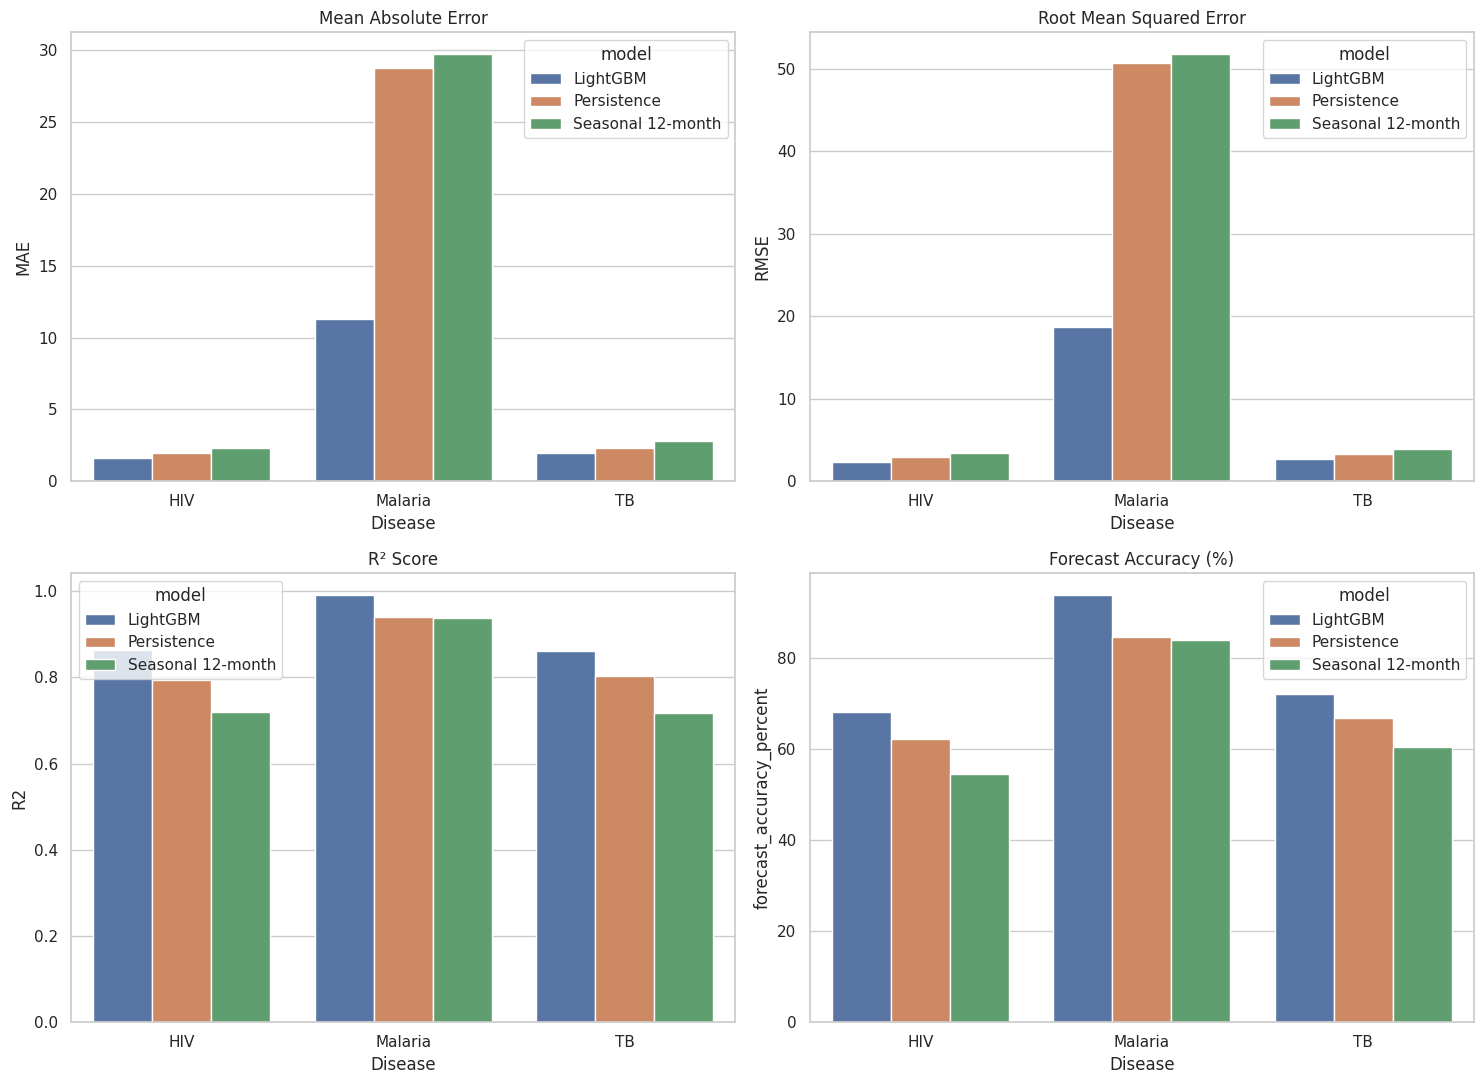

In [38]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(15, 11)
)

metrics_to_plot = [
    ("MAE", "Mean Absolute Error", axes[0, 0]),
    ("RMSE", "Root Mean Squared Error", axes[0, 1]),
    ("R2", "R² Score", axes[1, 0]),
    (
        "forecast_accuracy_percent",
        "Forecast Accuracy (%)",
        axes[1, 1]
    )
]

for column, title, ax in metrics_to_plot:

    sns.barplot(
        data=evaluation_matrix,
        x="disease",
        y=column,
        hue="model",
        ax=ax
    )

    ax.set_title(title)
    ax.set_xlabel("Disease")

plt.tight_layout()
plt.show()